In [1]:
import gymnasium as gym
import numpy as np
import math
import os
import configparser
from sb3_contrib.common.maskable.policies import MaskableActorCriticPolicy
from sb3_contrib.common.wrappers import ActionMasker
from sb3_contrib.ppo_mask import MaskablePPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
import matplotlib.pyplot as plt
from sb3_contrib.common.maskable.utils import get_action_masks



In [2]:
from src.hpc_env import HPCenv
from src.validation import Validation
from src.training import Train
from src.baseline import PercentileBaseline
from src.utils import mask_fn, get_config_as_dict
from src.carbon_intensity import CarbonIntensity

In [3]:
# Use interactive widget backend if ipympl is available; otherwise fallback to inline
try:
    import ipympl  # noqa: F401
    get_ipython().run_line_magic('matplotlib', 'widget')
except Exception:
    get_ipython().run_line_magic('matplotlib', 'inline')
    print('ipympl not available; using inline Matplotlib backend. Install with `pip install ipympl` for widgets.')


ipympl not available; using inline Matplotlib backend. Install with `pip install ipympl` for widgets.


In [4]:
WORKLOAD_PATH = "data/workloads/lublin_256.swf"

# Load config with explicit path and typed parsing
config = configparser.ConfigParser()
config_path = os.path.join(os.getcwd(), 'config_file', 'config.ini')
config.read(config_path)

['/Users/mikkeldahl/green_scheduler_v2/config_file/config.ini']

## Model validation

In [5]:
val = Validation()

In [6]:
val.load_dir("results/CI_B8192_RC_LR-00003_ETA5.0_C-None_Lu")
processed_stats, raw_stats = val.run_baselines(n_eval_episodes=1, mode="validation")

run time mean:  3087.737019315967
run time std:  12205.009945609008
Max Allocated Processors: 128 ;max node: 256 ;max procs: 256 ;max execution time: 160745
run time mean:  3087.737019315967
run time std:  12205.009945609008
Max Allocated Processors: 128 ;max node: 256 ;max procs: 256 ;max execution time: 160745
run time mean:  3087.737019315967
run time std:  12205.009945609008
Max Allocated Processors: 128 ;max node: 256 ;max procs: 256 ;max execution time: 160745
run time mean:  3087.737019315967
run time std:  12205.009945609008
Max Allocated Processors: 128 ;max node: 256 ;max procs: 256 ;max execution time: 160745
Executing baseline:  10-percentile Baseline
Episode  0
Executing baseline:  25-percentile Baseline
Episode  0
Executing baseline:  50-percentile Baseline
Episode  0
Executing baseline:  FCFS Baseline
Episode  0


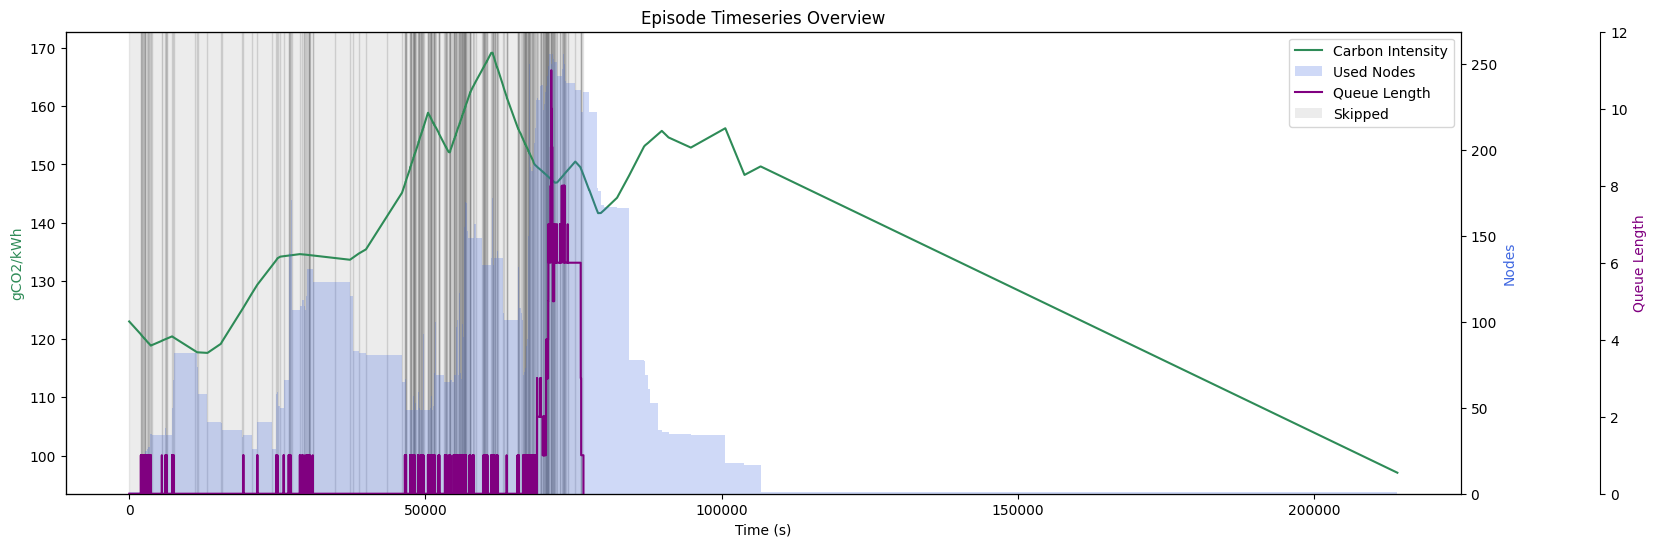

In [7]:
# Render timeseries for the first FCFS baseline episode
png_path, fig = val.render_timeseries_plot(
    raw_stats['FCFS Baseline']['action_traces'],
    name='fcfs_baseline_episode0',
    episode_index=0,
)
fig
